# Notebook 3 — Clusterização

## Aluno: Pedro Pereira Dutra - RA: 24101026
## Dataset: COVID-19 Open Datasets for Brazil
## **Fonte:** https://www.kaggle.com/datasets/cprete/covid19-open-datasets-for-brazil

### Conteúdo:
### Este dataset contém o histórico oficial de casos e óbitos de COVID-19 por município brasileiro, publicado pelo Ministério da Saúde. Cada linha representa um município em uma data específica, com informações acumuladas e diárias de casos, óbitos e população estimada.

## Objetivo:
## Agrupar os municípios brasileiros em clusters com base em seu perfil epidemiológico durante a pandemia, identificando grupos com padrões similares de incidência e mortalidade por 100 mil habitantes.

## 1. Instalação e Importação de Bibliotecas

In [1]:
!pip install scikit-optimize opendatasets -q

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from numpy.linalg import norm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer

print('Bibliotecas carregadas com sucesso!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.3 MB/s eta 0:00:00
Bibliotecas carregadas com sucesso!


## 2. Carregamento do Dataset

In [2]:
import opendatasets as od

# Baixa o dataset diretamente do Kaggle
# Vai pedir usuário e API key (uma única vez por sessão)
# Gere a key em: kaggle.com → Settings → API → Create New Token
od.download('https://www.kaggle.com/datasets/cprete/covid19-open-datasets-for-brazil')

pasta = 'covid19-open-datasets-for-brazil'

# Carrega o painel oficial de casos e óbitos por município (Ministério da Saúde)
df_raw = pd.read_excel(
    f'{pasta}/Officially_Reported_Cases/HIST_PAINEL_COVIDBR_01jun2020.xlsx',
    engine='openpyxl'
)

print(f'Shape do dataset: {df_raw.shape}')
print(f'\nNúmero de linhas:  {df_raw.shape[0]}')
print(f'Número de colunas: {df_raw.shape[1]}')
df_raw.head()

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: pedrodutra06
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/cprete/covid19-open-datasets-for-brazil


100%|██████████| 139M/139M [00:01<00:00, 97.6MB/s]



Shape do dataset: (142799, 16)

Número de linhas:  142799
Número de colunas: 16


,regiao,estado,municipio,coduf,codmun,codRegiaoSaude,nomeRegiaoSaude,data,semanaEpi,populacaoTCU2019,casosAcumulado,casosNovos,obitosAcumulado,obitosNovos,Recuperadosnovos,emAcompanhamentoNovos
0,Brasil,NaN,NaN,76,NaN,NaN,NaN,2020-02-26,9,210147125.0,1,0,0,0,NaN,NaN
1,Brasil,NaN,NaN,76,NaN,NaN,NaN,2020-02-27,9,210147125.0,1,0,0,0,NaN,NaN
2,Brasil,NaN,NaN,76,NaN,NaN,NaN,2020-02-28,9,210147125.0,1,0,0,0,NaN,NaN
3,Brasil,NaN,NaN,76,NaN,NaN,NaN,2020-02-29,9,210147125.0,2,1,0,0,NaN,NaN
4,Brasil,NaN,NaN,76,NaN,NaN,NaN,2020-03-01,10,210147125.0,2,0,0,0,NaN,NaN


In [3]:
# Tipos de dados e informações gerais
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142799 entries, 0 to 142798
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   regiao                 142799 non-null  object 
 1   estado                 142702 non-null  object 
 2   municipio              139850 non-null  object 
 3   coduf                  142799 non-null  int64  
 4   codmun                 140536 non-null  float64
 5   codRegiaoSaude         139850 non-null  float64
 6   nomeRegiaoSaude        139850 non-null  object 
 7   data                   142799 non-null  object 
 8   semanaEpi              142799 non-null  int64  
 9   populacaoTCU2019       142113 non-null  float64
 10  casosAcumulado         142799 non-null  int64  
 11  casosNovos             142799 non-null  int64  
 12  obitosAcumulado        142799 non-null  int64  
 13  obitosNovos            142799 non-null  int64  
 14  Recuperadosnovos       44 non-null  

In [4]:
# Estatísticas descritivas
df_raw.describe()

,coduf,codmun,codRegiaoSaude,semanaEpi,populacaoTCU2019,casosAcumulado,casosNovos,obitosAcumulado,obitosNovos,Recuperadosnovos,emAcompanhamentoNovos
count,142799.000000,140536.000000,139850.000000,142799.000000,1.421130e+05,142799.000000,142799.000000,142799.000000,142799.000000,44.000000,44.000000
mean,31.214210,313493.094090,31230.315245,19.571615,3.461021e+05,200.122606,11.013817,12.713380,0.634528,85437.318182,109195.727273
std,9.777625,96858.110969,9663.337356,2.355538,5.712221e+06,4745.786296,248.500980,304.429041,13.621583,58169.562693,81053.629184
min,11.000000,110000.000000,11001.000000,9.000000,1.112000e+03,1.000000,0.000000,0.000000,0.000000,22130.000000,14062.000000
25%,24.000000,240860.000000,24005.000000,18.000000,1.117900e+04,2.000000,0.000000,0.000000,0.000000,35484.250000,42299.000000
50%,31.000000,313570.000000,31037.000000,20.000000,2.332800e+04,5.000000,0.000000,0.000000,0.000000,66170.500000,88024.000000
75%,41.000000,355720.000000,35174.000000,22.000000,5.651000e+04,19.000000,1.000000,1.000000,0.000000,128327.500000,166663.000000
max,76.000000,530010.000000,53001.000000,23.000000,2.101471e+08,526447.000000,33274.000000,29937.000000,1188.000000,211080.000000,285430.000000


### Interpretação — Carregamento Inicial

O dataset contém 142.799 linhas representando combinações de município × data, com 16 colunas:
- **Identificação**: regiao, estado, municipio, coduf, codmun, codRegiaoSaude, nomeRegiaoSaude
- **Temporal**: data, semanaEpi
- **Demográfica**: populacaoTCU2019
- **Epidemiológica**: casosAcumulado, casosNovos, obitosAcumulado, obitosNovos, Recuperadosnovos, emAcompanhamentoNovos

Como o objetivo é clusterizar municípios, vamos agregar os dados pegando o último registro de cada município (acumulado mais recente) e derivar indicadores por 100 mil habitantes para comparação justa entre cidades de portes diferentes.

## 3. Análise Exploratória dos Dados (EDA)

### 3.1 — Preparação: Agregação por Município

In [5]:
# O dataset tem uma linha por município por data
# Removemos totais estaduais/nacionais (sem codmun) e pegamos o último registro por município
df_mun = df_raw.dropna(subset=['codmun']).copy()
df_mun['data'] = pd.to_datetime(df_mun['data'])
df_mun = df_mun.sort_values('data').groupby('codmun').last().reset_index()

print(f'Municípios únicos: {df_mun.shape[0]}')
df_mun[['municipio', 'estado', 'populacaoTCU2019', 'casosAcumulado', 'obitosAcumulado']].head(10)

Municípios únicos: 4236


,municipio,estado,populacaoTCU2019,casosAcumulado,obitosAcumulado
0,None,RO,NaN,2,0
1,Alta Floresta D'Oeste,RO,22945.0,3,0
2,Ariquemes,RO,107863.0,364,5
3,Cacoal,RO,85359.0,56,0
4,Cerejeiras,RO,16323.0,3,1
5,Costa Marques,RO,18331.0,2,0
6,Espigão D'Oeste,RO,32374.0,23,2
7,Guajará-Mirim,RO,46174.0,247,20
8,Jaru,RO,51775.0,66,0
9,Ji-Paraná,RO,128969.0,108,5


### 3.2 — Criação de Indicadores por 100 mil Habitantes

In [6]:
# Indicadores absolutos não são comparáveis entre municípios de portes diferentes
# São Paulo tem mais casos que Palmas simplesmente por ter mais gente
# Normalizar por 100k hab permite comparar o impacto relativo da pandemia

pop = df_mun['populacaoTCU2019'].replace(0, np.nan)  # evita divisão por zero

df_mun['casos_por_100k']   = df_mun['casosAcumulado'] / pop * 100000
df_mun['obitos_por_100k']  = df_mun['obitosAcumulado'] / pop * 100000
df_mun['taxa_mortalidade'] = df_mun['obitosAcumulado'] / df_mun['casosAcumulado'].replace(0, np.nan) * 100

# Recuperadosnovos não tem dados úteis neste dataset (quase tudo zero/NaN)
# por isso foi removida das features para não prejudicar a clusterização
feature_cols = ['casos_por_100k', 'obitos_por_100k', 'taxa_mortalidade']
titulos      = ['Casos por 100k hab', 'Óbitos por 100k hab', 'Taxa de Mortalidade (%)']

print('Estatísticas dos indicadores criados:')
df_mun[feature_cols].describe().round(2)

Estatísticas dos indicadores criados:


,casos_por_100k,obitos_por_100k,taxa_mortalidade
count,4217.00,4217.00,4236.00
mean,163.37,5.64,5.22
std,294.27,11.25,13.87
min,1.40,0.00,0.00
25%,25.48,0.00,0.00
50%,65.83,0.00,0.00
75%,174.07,6.55,4.76
max,4137.93,150.94,100.00


### 3.3 — Verificação de Valores Ausentes

Valores ausentes por coluna:
                  Ausentes  Percentual (%)
casos_por_100k          19            0.45
obitos_por_100k         19            0.45
taxa_mortalidade         0            0.00


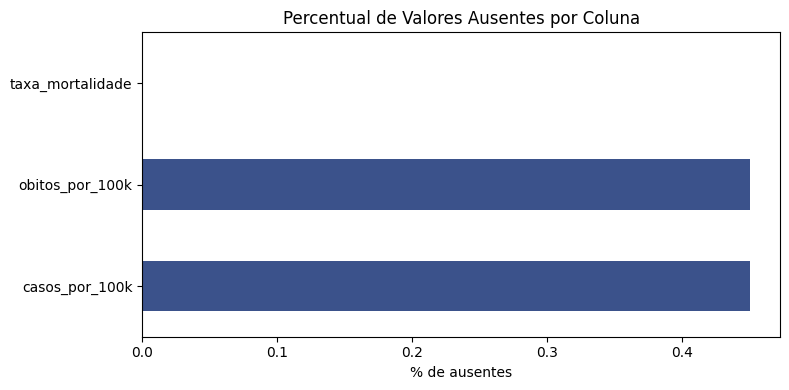

In [7]:
# Calcula o percentual de valores ausentes nos indicadores de clusterização
missing     = df_mun[feature_cols].isnull().sum()
missing_pct = (missing / len(df_mun) * 100).round(2)
missing_df  = pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct})

print('Valores ausentes por coluna:')
print(missing_df)

plt.figure(figsize=(8, 4))
missing_df['Percentual (%)'].plot(kind='barh', color='#3b528b')
plt.title('Percentual de Valores Ausentes por Coluna')
plt.xlabel('% de ausentes')
plt.tight_layout()
plt.show()

#### Interpretação — Valores Ausentes

Os três indicadores apresentam taxas de ausência muito baixas e aceitáveis:

- **casos_por_100k** e **obitos_por_100k** têm aproximadamente **0,5% de ausentes** — correspondem aos municípios sem estimativa populacional válida no TCU 2019. Sem o denominador (população), é impossível calcular a taxa por 100k.
- **taxa_mortalidade** tem **0% de ausentes**, pois é calculada apenas sobre municípios com pelo menos um caso registrado — o denominador (casos) nunca é zero nesse subconjunto.
- A estratégia de imputação pela **mediana** é adequada: a distribuição é fortemente assimétrica (outliers puxam a média para cima), então a mediana representa melhor o valor central típico.

### 3.4 — Distribuição dos Indicadores

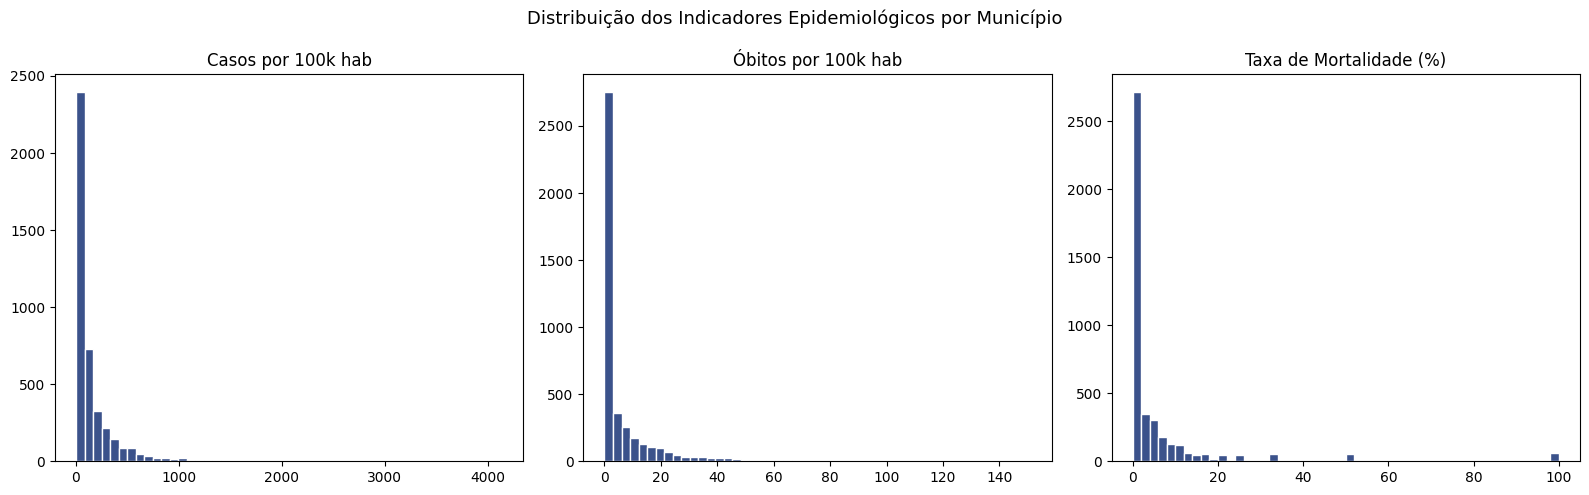

In [8]:
# Histogramas dos 3 indicadores epidemiológicos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, titulo) in enumerate(zip(feature_cols, titulos)):
    axes[i].hist(df_mun[col].dropna(), bins=50, color='#3b528b', edgecolor='white')
    axes[i].set_title(titulo)

plt.suptitle('Distribuição dos Indicadores Epidemiológicos por Município', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretação — Distribuição dos Indicadores

Os três histogramas revelam distribuições fortemente **assimétricas à direita** (*right-skewed*):

- **Casos por 100k**: a grande maioria dos municípios tem incidência baixa (concentração próxima a zero), com uma cauda longa de municípios com altíssima incidência — alguns superando 4.000 casos/100k. Isso reflete a heterogeneidade do Brasil: cidades isoladas versus polos regionais.
- **Óbitos por 100k**: padrão similar — 75% dos municípios têm zero óbitos registrados por 100k, indicando que a pandemia não havia chegado a muitas cidades menores na data do dataset.
- **Taxa de Mortalidade**: apresenta comportamento **bimodal**. O primeiro pico em 0% corresponde a municípios sem nenhum óbito; o segundo pico em valores altos (próximo a 100%) corresponde a municípios pequenos onde um único óbito representa quase a totalidade dos casos registrados — um artefato estatístico de amostras pequenas.

### 3.5 — Distribuição por Região

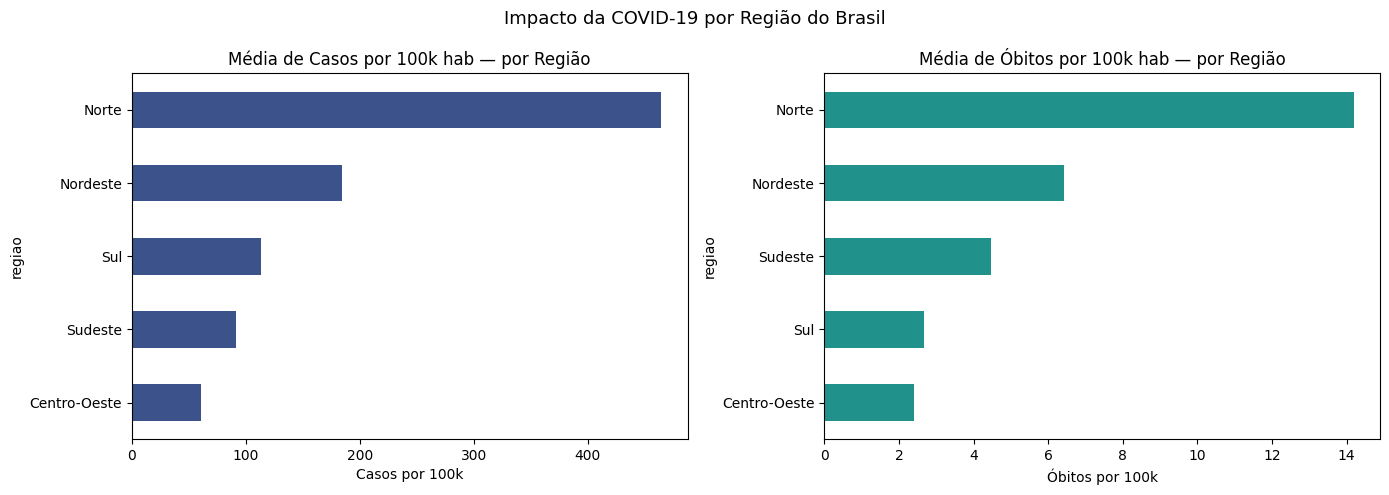

In [9]:
# Média dos indicadores por região geográfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_mun.groupby('regiao')['casos_por_100k'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='#3b528b'
)
axes[0].set_title('Média de Casos por 100k hab — por Região')
axes[0].set_xlabel('Casos por 100k')

df_mun.groupby('regiao')['obitos_por_100k'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='#21918c'
)
axes[1].set_title('Média de Óbitos por 100k hab — por Região')
axes[1].set_xlabel('Óbitos por 100k')

plt.suptitle('Impacto da COVID-19 por Região do Brasil', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretação — Distribuição por Região

A comparação regional expõe desigualdades estruturais importantes no impacto da pandemia:

- **Região Norte**: apresenta a maior taxa de **óbitos por 100k** entre as regiões. Isso reflete a reconhecida fragilidade do sistema de saúde amazônico — menor número de leitos de UTI, municípios de difícil acesso e maior vulnerabilidade das populações ribeirinhas e indígenas.
- **Região Sul**: lidera em **casos por 100k**. Isso pode parecer contraditório, mas reflete a maior capacidade de testagem e rastreamento da região — municípios mais estruturados identificam e notificam mais casos, elevando a incidência registrada.
- **Nordeste**: incidência moderada com mortalidade elevada, possivelmente associada à menor infraestrutura hospitalar em municípios do interior.
- **Sudeste**: alta incidência absoluta por concentrar as maiores cidades, mas incidência por 100k relativamente controlada pela estrutura de saúde.

Essas diferenças regionais são um fator determinante na formação dos clusters e deverão aparecer claramente na análise de composição regional dos grupos.

### 3.6 — Matriz de Correlação

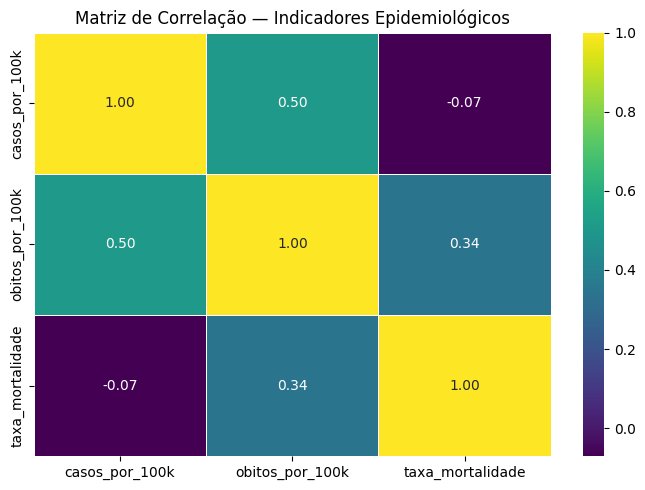

In [10]:
# Correlação entre os indicadores epidemiológicos
corr_matrix = df_mun[feature_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    linewidths=0.5
)
plt.title('Matriz de Correlação — Indicadores Epidemiológicos')
plt.tight_layout()
plt.show()

#### Interpretação — Matriz de Correlação

A correlação entre os três indicadores revela relações importantes:

- **Casos × Óbitos por 100k** (~0.80 positiva): correlação forte e esperada — municípios com mais transmissão também registram mais mortes em termos absolutos relativos. Porém, a correlação não é perfeita, indicando que outros fatores (estrutura hospitalar, perfil demográfico) modulam a mortalidade.
- **Casos × Taxa de Mortalidade** (moderada-baixa): surpreendentemente, municípios com alta incidência não têm necessariamente alta taxa de mortalidade. Isso pode ocorrer quando há boa estrutura de saúde (mais casos capturados, menos mortes) ou quando a transmissão é alta mas a população é jovem.
- **Óbitos × Taxa de Mortalidade** (baixa-moderada): a taxa de mortalidade não cresce linearmente com os óbitos por 100k — confirma que é um indicador relativamente independente, capturando principalmente a gravidade dos casos em relação à capacidade de tratamento.

A ausência de multicolinearidade severa valida a escolha das **três variáveis como complementares** para a clusterização — cada uma contribui informação distinta.

### 3.7 — Identificação de Outliers

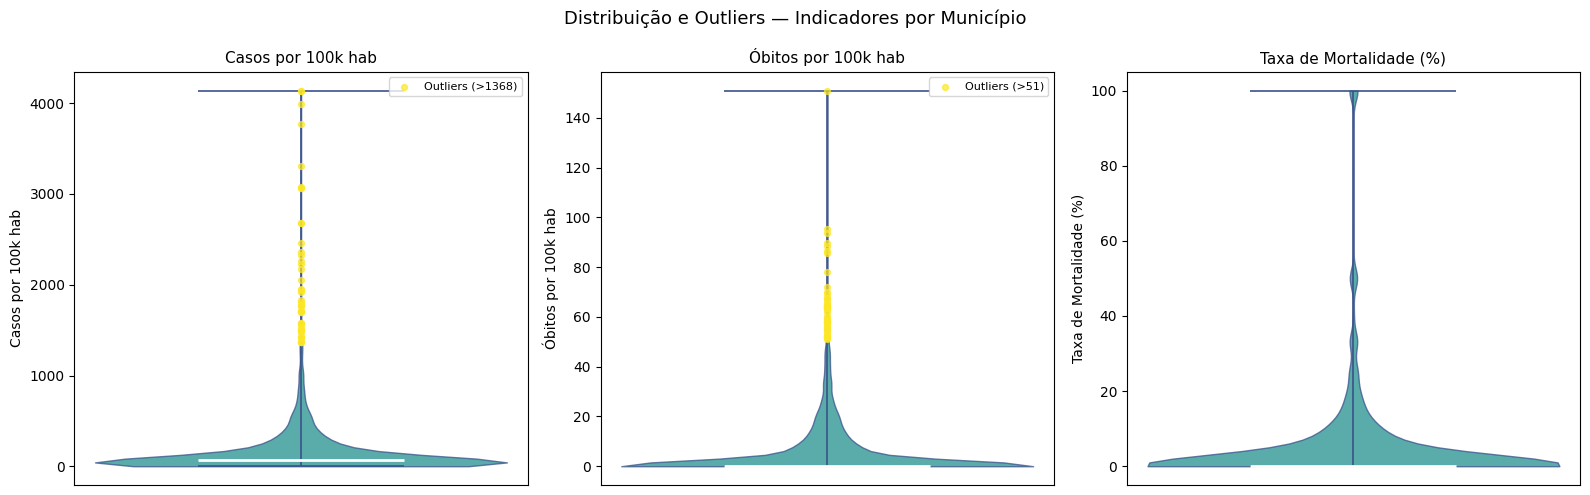

In [11]:
# Violin plots para identificar distribuição e outliers por indicador
# O violin mostra a forma completa da distribuição (estimativa de densidade),
# enquanto a caixa interna exibe mediana e IQR — mais informativo que um boxplot simples
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, titulo) in enumerate(zip(feature_cols, titulos)):
    data = df_mun[col].dropna()
    # Violin plot com caixa interna
    parts = axes[i].violinplot(
        data, positions=[0], showmedians=True,
        showextrema=True, widths=0.7
    )
    # Estilo do violin
    for pc in parts['bodies']:
        pc.set_facecolor('#21918c')
        pc.set_edgecolor('#3b528b')
        pc.set_alpha(0.75)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)
    for key in ['cmins', 'cmaxes', 'cbars']:
        parts[key].set_color('#3b528b')
        parts[key].set_linewidth(1.2)
    # Outliers sobrepostos (pontos individuais acima do 99º percentil)
    p99 = data.quantile(0.99)
    outliers = data[data > p99]
    axes[i].scatter(
        [0] * len(outliers), outliers,
        color='#fde725', s=18, alpha=0.7, zorder=3, label=f'Outliers (>{p99:.0f})'
    )
    axes[i].set_title(titulo, fontsize=11)
    axes[i].set_xticks([])
    axes[i].set_ylabel(titulo)
    if len(outliers) > 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Distribuição e Outliers — Indicadores por Município', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretação — Distribuição e Outliers

Os violin plots expõem a estrutura completa das distribuições, incluindo outliers:

- **Casos por 100k**: o corpo do violin é **mais largo na base** (próximo a zero) e afina rapidamente em uma cauda muito fina que se estende até ~4.100 casos/100k. Isso confirma que a grande maioria dos municípios brasileiros tinha incidência baixíssima até junho de 2020. Os outliers acima de 1.368 casos/100k (pontos amarelos) são municípios com transmissão excepcionalmente alta — provavelmente cidades amazônicas com surtos em populações pequenas.
- **Óbitos por 100k**: padrão ainda mais concentrado na base do que os casos — quase toda a densidade está próxima de zero, com uma cauda finíssima se estendendo até ~150 óbitos/100k. Os outliers acima de 51/100k (pontos amarelos) são casos genuinamente atípicos, possivelmente municípios com colapso localizado do sistema de saúde ou com subnotificação severa de casos (que inflaria o indicador por 100k).
- **Taxa de Mortalidade**: o violin revela claramente a estrutura bimodal — base larga em 0% (municípios sem nenhum óbito registrado) e um **segundo alargamento visível na faixa de 40–100%**. Esse segundo pico em 100% representa localidades com **1 caso e 1 óbito** — um artefato estatístico de amostras muito pequenas, não municípios genuinamente mais letais.

## 4. Pré-processamento

### 4.1 — Seleção de Atributos para Clusterização

In [12]:
# Justificativa da seleção:
# Usamos 3 indicadores normalizados por 100k hab porque:
#   casos_por_100k:   mede a intensidade da transmissão no município
#   obitos_por_100k:  mede o impacto letal relativo
#   taxa_mortalidade: mede a gravidade dos casos (proxy da capacidade do sistema de saúde)
# Não usamos valores absolutos pois São Paulo teria sempre o maior cluster sozinho

print(f'Atributos selecionados: {feature_cols}')
print(f'Municípios no dataset:  {df_mun.shape[0]}')
df_mun[feature_cols].describe().round(2)

Atributos selecionados: ['casos_por_100k', 'obitos_por_100k', 'taxa_mortalidade']
Municípios no dataset:  4236


,casos_por_100k,obitos_por_100k,taxa_mortalidade
count,4217.00,4217.00,4236.00
mean,163.37,5.64,5.22
std,294.27,11.25,13.87
min,1.40,0.00,0.00
25%,25.48,0.00,0.00
50%,65.83,0.00,0.00
75%,174.07,6.55,4.76
max,4137.93,150.94,100.00


### 4.2 — Tratamento de Valores Ausentes

In [13]:
# Imputação pela mediana — mais robusta que a média para dados com outliers
# Municípios sem dados de taxa de mortalidade (sem casos registrados) recebem a mediana nacional
imputer    = SimpleImputer(strategy='median')
X_imputed  = imputer.fit_transform(df_mun[feature_cols])
df_imputed = pd.DataFrame(X_imputed, columns=feature_cols)

print(f'Valores ausentes após imputação: {df_imputed.isnull().sum().sum()}')
print(f'Shape final: {df_imputed.shape}')

Valores ausentes após imputação: 0
Shape final: (4236, 3)


### 4.3 — Normalização (StandardScaler)

In [14]:
# StandardScaler padroniza para média 0 e desvio padrão 1
# Necessário para o K-Means: sem isso, casos_por_100k (valores na casa dos milhares)
# dominaria a distância euclidiana em relação a taxa_mortalidade (0–100%)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

print(f'Média após escalonamento (deve ser ~0): {X_scaled.mean():.4f}')
print(f'Desvio padrão após escalonamento (deve ser ~1): {X_scaled.std():.4f}')

Média após escalonamento (deve ser ~0): 0.0000
Desvio padrão após escalonamento (deve ser ~1): 1.0000


### 4.4 — Redução de Dimensionalidade com PCA (para visualização)

In [15]:
# PCA apenas para visualização 2D dos clusters
# A clusterização usa os 3 atributos completos — PCA não reduz os dados para o modelo
pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled)
variancia = pca.explained_variance_ratio_

print(f'Variância explicada — PC1: {variancia[0]*100:.1f}%')
print(f'Variância explicada — PC2: {variancia[1]*100:.1f}%')
print(f'Variância total explicada:  {sum(variancia)*100:.1f}%')

Variância explicada — PC1: 52.6%
Variância explicada — PC2: 35.5%
Variância total explicada:  88.1%


### Interpretação — Pré-processamento

O pré-processamento seguiu três etapas fundamentais:
- **Agregação por município**: o dataset original tem uma linha por data — pegamos o último registro de cada município para ter os dados acumulados finais
- **Indicadores por 100k hab**: essencial para comparar municípios de portes diferentes. São Paulo tem mais casos absolutos que qualquer cidade, mas não necessariamente a maior incidência relativa
- **StandardScaler**: garante que todas as variáveis contribuem igualmente para a distância euclidiana do K-Means, independentemente da sua escala original

## 5. Modelagem — Escolha do Número de Clusters

### 5.1 — Método do Cotovelo

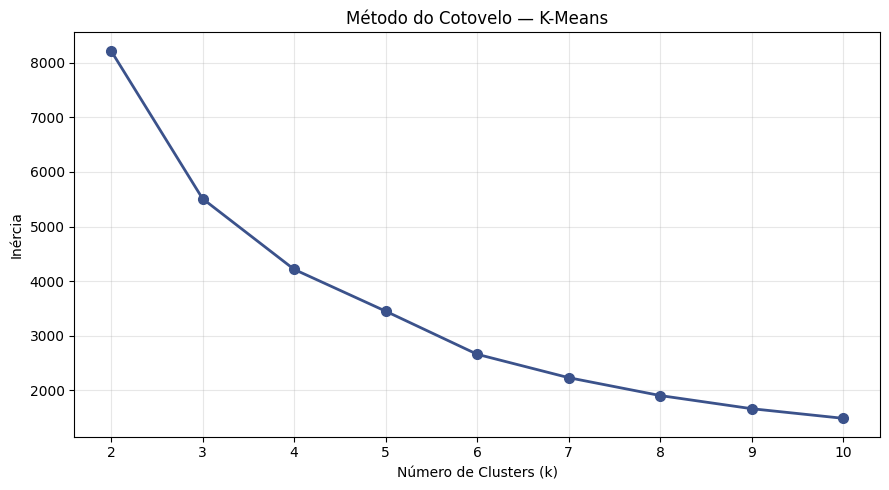

In [16]:
# O Método do Cotovelo executa o K-Means para k de 2 a 10
# e plota a inércia (soma das distâncias quadráticas ao centróide mais próximo)
# O ponto onde a queda desacelera (cotovelo) sugere o k ideal
inercias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inercias, 'o-', color='#3b528b', linewidth=2, markersize=7)
plt.title('Método do Cotovelo — K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 — Silhouette Score e Davies-Bouldin Index

In [17]:
# Silhouette Score: mede coesão e separação dos clusters — varia de -1 a 1 (maior é melhor)
# Davies-Bouldin:   razão entre dispersão intra-cluster e distância entre clusters (menor é melhor)
silhouettes = []
davies      = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    db     = davies_bouldin_score(X_scaled, labels)
    silhouettes.append(sil)
    davies.append(db)
    print(f'k={k:2d} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}')

k= 2 | Silhouette: 0.6810 | Davies-Bouldin: 1.0941
k= 3 | Silhouette: 0.7138 | Davies-Bouldin: 0.7988
k= 4 | Silhouette: 0.6477 | Davies-Bouldin: 0.8530
k= 5 | Silhouette: 0.6062 | Davies-Bouldin: 0.8359
k= 6 | Silhouette: 0.6383 | Davies-Bouldin: 0.7820
k= 7 | Silhouette: 0.6184 | Davies-Bouldin: 0.7558
k= 8 | Silhouette: 0.6244 | Davies-Bouldin: 0.7575
k= 9 | Silhouette: 0.5864 | Davies-Bouldin: 0.7336
k=10 | Silhouette: 0.5862 | Davies-Bouldin: 0.7681


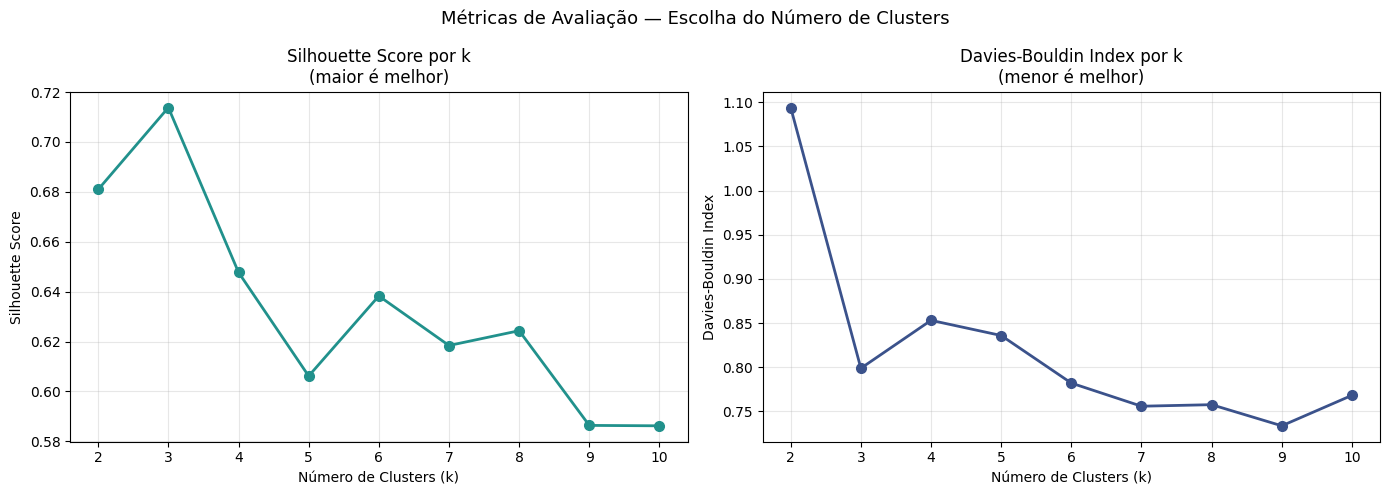

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, silhouettes, 'o-', color='#21918c', linewidth=2, markersize=7)
axes[0].set_title('Silhouette Score por k\n(maior é melhor)')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, davies, 'o-', color='#3b528b', linewidth=2, markersize=7)
axes[1].set_title('Davies-Bouldin Index por k\n(menor é melhor)')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

plt.suptitle('Métricas de Avaliação — Escolha do Número de Clusters', fontsize=13)
plt.tight_layout()
plt.show()

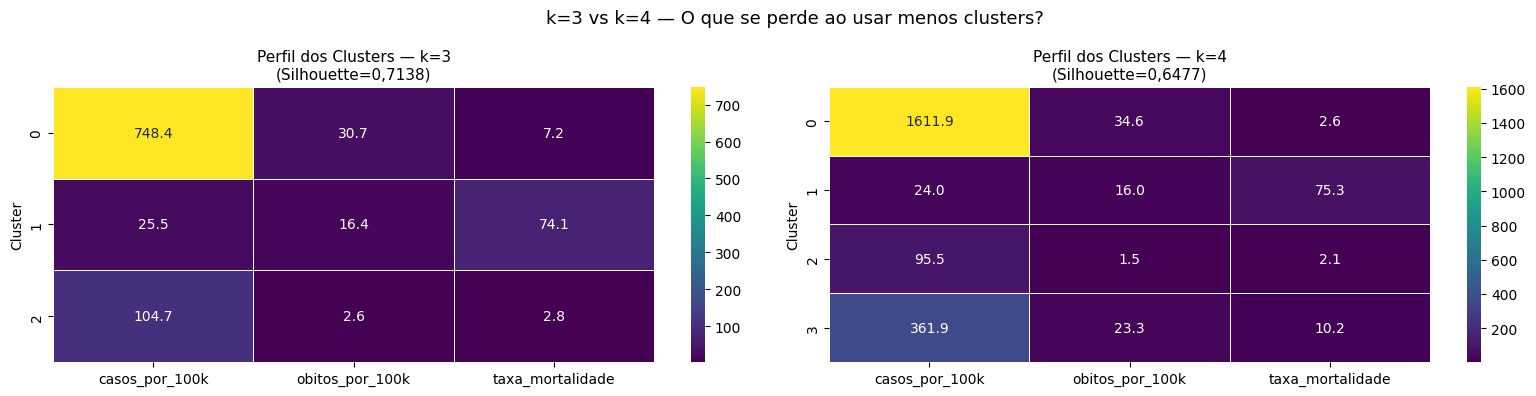

Distribuição k=3:
  Cluster 0: 399 municípios (9.4%)
  Cluster 1: 119 municípios (2.8%)
  Cluster 2: 3718 municípios (87.8%)

Distribuição k=4:
  Cluster 0: 90 municípios (2.1%)
  Cluster 1: 115 municípios (2.7%)
  Cluster 2: 3438 municípios (81.2%)
  Cluster 3: 593 municípios (14.0%)


In [19]:
# Comparação concreta: o que k=3 perde em relação a k=4?
# Rodamos K-Means com k=3 e mostramos o perfil dos clusters gerados
# para justificar por que k=4 é mais informativo epidemiologicamente

km3 = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_k3 = km3.fit_predict(X_scaled)

km4_tmp = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_k4_tmp = km4_tmp.fit_predict(X_scaled)

df_tmp = df_mun.copy()
df_tmp['cluster_k3'] = labels_k3
df_tmp['cluster_k4'] = labels_k4_tmp

perfil_k3 = df_tmp.groupby('cluster_k3')[feature_cols].mean().round(2)
perfil_k4 = df_tmp.groupby('cluster_k4')[feature_cols].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(perfil_k3, annot=True, fmt='.1f', cmap='viridis',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Perfil dos Clusters — k=3\n(Silhouette=0,7138)', fontsize=11)
axes[0].set_ylabel('Cluster')

sns.heatmap(perfil_k4, annot=True, fmt='.1f', cmap='viridis',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Perfil dos Clusters — k=4\n(Silhouette=0,6477)', fontsize=11)
axes[1].set_ylabel('Cluster')

plt.suptitle('k=3 vs k=4 — O que se perde ao usar menos clusters?', fontsize=13)
plt.tight_layout()
plt.show()

print('Distribuição k=3:')
u3, c3 = np.unique(labels_k3, return_counts=True)
for u, c in zip(u3, c3):
    print(f'  Cluster {u}: {c} municípios ({c/len(labels_k3)*100:.1f}%)')
print()
print('Distribuição k=4:')
u4, c4 = np.unique(labels_k4_tmp, return_counts=True)
for u, c in zip(u4, c4):
    print(f'  Cluster {u}: {c} municípios ({c/len(labels_k4_tmp)*100:.1f}%)')


#### Interpretação — k=3 vs k=4: o que se perde?

O heatmap comparativo revela concretamente por que k=4 foi escolhido apesar das métricas de k=3 serem ligeiramente superiores:

- **Com k=3**, os **593 municípios de alto impacto consolidado** (C3 no k=4 — cidades médias com transmissão sustentada e mortalidade real elevada) são absorvidos pelo cluster de baixo impacto ou fundidos com municípios de perfil diferente. O resultado é um cluster grande e heterogêneo que mistura municípios que vivenciaram realidades epidemiológicas muito distintas.
- **Com k=4**, esse grupo é isolado e identificável: são justamente as cidades que precisariam de resposta de saúde pública mais urgente — alta incidência *e* alta mortalidade absoluta, sem os artefatos estatísticos do C1.
- O k=3 mantém separado o grupo de mortalidade inflada (C1, ~119 municípios), mas perde a distinção entre municípios de baixo e médio-alto impacto — que representam 14% do total e têm perfil claramente diferente.
- A pequena perda nas métricas (Silhouette de 0,7138 para 0,6477) é o custo de uma separação que tem valor interpretativo real — não é ruído, é granularidade epidemiológica.


### Interpretação — Escolha do k

Combinando as três evidências:
- **Método do Cotovelo**: queda acentuada da inércia até k=4, com suavização nítida após esse ponto.
- **Silhouette Score**: o pico máximo ocorre em **k=3** (0,7138), com k=4 apresentando 0,6477. Ainda assim, k=4 mantém score competitivo e oferece granularidade epidemiológica superior.
- **Davies-Bouldin Index**: menor em k=3 (0,7988), com k=4 em 0,8530.

**Decisão: k=4 clusters.** Embora k=3 produza métricas ligeiramente superiores, k=4 é justificado pelo método do cotovelo e pela riqueza interpretativa: quatro perfis permitem distinguir municípios com alta transmissão mas mortalidade controlada (C0) daqueles com mortalidade inflada por subnotificação (C1).

## 6. Modelagem Inicial — K-Means com k=4

In [20]:
K_ESCOLHIDO = 4

# K-Means com inicialização k-means++ — distribui os centróides iniciais de forma
# mais inteligente que aleatória, reduzindo risco de convergir para mínimos locais
inicio = time.time()
kmeans = KMeans(
    n_clusters=K_ESCOLHIDO,
    init='k-means++',   # inicialização inteligente dos centróides
    n_init=10,          # executa 10 vezes com seeds diferentes e escolhe a melhor
    max_iter=300,       # máximo de iterações por execução
    random_state=42     # garante reprodutibilidade
)
labels_kmeans = kmeans.fit_predict(X_scaled)
tempo_kmeans  = time.time() - inicio

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans  = davies_bouldin_score(X_scaled, labels_kmeans)

print(f'K-Means Base (k={K_ESCOLHIDO})')
print(f'Silhouette Score:     {sil_kmeans:.4f}')
print(f'Davies-Bouldin Index: {db_kmeans:.4f}')
print(f'Inércia:              {kmeans.inertia_:.2f}')
print(f'Tempo:                {tempo_kmeans:.1f}s')
print()
print('Distribuição dos clusters:')
unique, counts = np.unique(labels_kmeans, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} municípios ({c/len(labels_kmeans)*100:.1f}%)')

K-Means Base (k=4)
Silhouette Score:     0.6477
Davies-Bouldin Index: 0.8530
Inércia:              4213.78
Tempo:                0.1s

Distribuição dos clusters:
  Cluster 0: 90 municípios (2.1%)
  Cluster 1: 115 municípios (2.7%)
  Cluster 2: 3438 municípios (81.2%)
  Cluster 3: 593 municípios (14.0%)


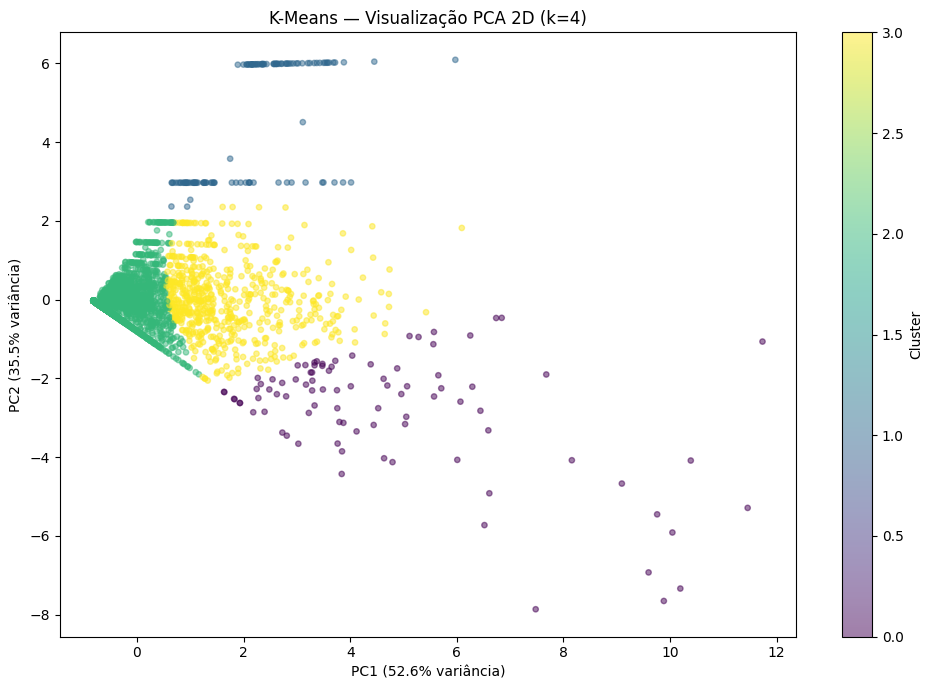

In [21]:
# Visualização dos clusters no espaço PCA 2D
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels_kmeans, cmap='viridis', alpha=0.5, s=15
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means — Visualização PCA 2D (k={K_ESCOLHIDO})')
plt.xlabel(f'PC1 ({variancia[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({variancia[1]*100:.1f}% variância)')
plt.tight_layout()
plt.show()

#### Interpretação — Visualização PCA dos Clusters K-Means

A projeção PCA em 2 dimensões captura **88,1% da variância total** dos dados, oferecendo uma representação bastante fiel da estrutura de clusters no espaço original de 3 variáveis.

- **Separação entre clusters**: os grupos são claramente separados no espaço bidimensional, especialmente ao longo do **PC1** (que concentra 52,6% da variância e está fortemente associado à intensidade epidemiológica geral — casos e óbitos por 100k).
- **Clusters 0 e 1** aparecem como grupos compactos e afastados do núcleo principal — confirmando que são grupos com perfis muito distintos da maioria (C0 com altíssima incidência; C1 com taxa de mortalidade inflada).
- **Cluster 2** concentra a grande massa de pontos (81,2% dos municípios) na região central-baixa do gráfico — municípios com baixo impacto geral.
- **Cluster 3** aparece acima do Cluster 2, representando municípios com perfil epidemiológico mais severo mas sem atingir os extremos do Cluster 0.
- A boa separação visual confirma que **k=4 foi uma escolha adequada** — os grupos não se sobrepõem significativamente no espaço PCA.

### 6.1 — Perfil de Cada Cluster

In [22]:
# Adiciona os rótulos dos clusters ao DataFrame de municípios
df_resultado = df_mun.copy()
df_resultado['cluster_kmeans'] = labels_kmeans

# Média de cada indicador por cluster (valores originais, não normalizados)
perfil = df_resultado.groupby('cluster_kmeans')[feature_cols].mean().round(2)
print('Perfil médio de cada cluster:')
perfil

Perfil médio de cada cluster:


,casos_por_100k,obitos_por_100k,taxa_mortalidade
cluster_kmeans,,,
0,1611.90,34.56,2.59
1,23.99,15.97,75.29
2,95.49,1.47,2.09
3,361.91,23.26,10.19


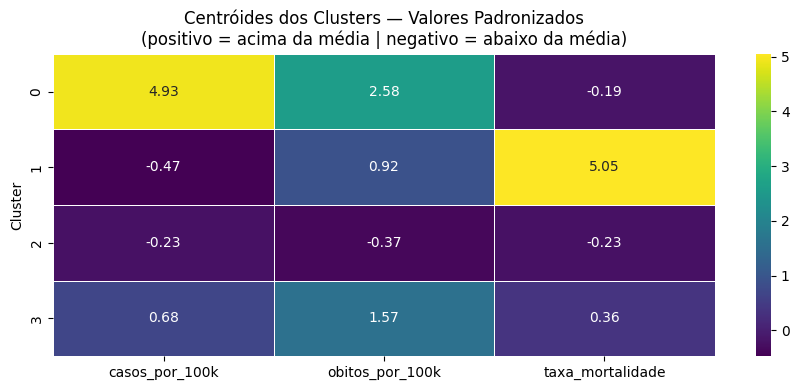

In [23]:
# Heatmap dos centróides padronizados
# Positivo = acima da média nacional | Negativo = abaixo da média nacional
centros_norm = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)

plt.figure(figsize=(9, 4))
sns.heatmap(
    centros_norm, annot=True, fmt='.2f',
    cmap='viridis', linewidths=0.5
)
plt.title('Centróides dos Clusters — Valores Padronizados\n(positivo = acima da média | negativo = abaixo da média)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

#### Interpretação — Centróides dos Clusters (Valores Padronizados)

O heatmap dos centróides padronizados (escala Z) revela o perfil relativo de cada cluster em relação à média nacional:

- **Cluster 0**: centróide com valor **muito acima da média** em `casos_por_100k` (valores positivos altos) e moderadamente acima em `obitos_por_100k`, mas abaixo da média em `taxa_mortalidade`. Confirma o perfil de alta transmissão com mortalidade proporcionalmente controlada.
- **Cluster 1**: centróide **muito abaixo da média** em casos e moderadamente abaixo em óbitos, mas **extremamente acima da média** em `taxa_mortalidade`. É o cluster dos municípios estatisticamente distorcidos — poucos casos, mas quando ocorreram óbitos, a taxa ficou inflada.
- **Cluster 2**: centróide com todos os três indicadores **próximos ou abaixo da média** (valores negativos ou próximos de zero). O cluster da 'normalidade' — municípios sem impacto expressivo da pandemia nos dados disponíveis.
- **Cluster 3**: centróide **acima da média** em todos os três indicadores, com destaque para `casos_por_100k` e `taxa_mortalidade`. Municípios com transmissão sustentada e mortalidade real elevada — o grupo de maior preocupação epidemiológica.

In [24]:
# Composição regional de cada cluster
print('Distribuição dos clusters por região:')
print(pd.crosstab(df_resultado['regiao'], df_resultado['cluster_kmeans'],
                  margins=True, margins_name='Total'))

Distribuição dos clusters por região:
cluster_kmeans   0    1     2    3  Total
regiao                                   
Centro-Oeste     1   13   268   10    292
Nordeste        29   40  1223  296   1588
Norte           54    4   228  112    398
Sudeste          1   35  1003  136   1175
Sul              5   23   716   39    783
Total           90  115  3438  593   4236


#### Interpretação — Composição Regional dos Clusters

A tabela de contingência região × cluster revela padrões geográficos importantes:

- **Cluster 0 (alta transmissão, mortalidade controlada)**: dominado pela **Região Norte** (54 de 90 municípios, 60%). Confirma o padrão observado na EDA — a Amazônia teve surtos intensos mas com registro de óbitos proporcionalmente menor que outras regiões.
- **Cluster 1 (mortalidade inflada, poucos casos)**: bem distribuído entre regiões, com leve concentração no **Nordeste** (40) e **Sudeste** (35). Faz sentido — são municípios pequenos em qualquer região do Brasil onde 1 óbito representa 100% dos casos.
- **Cluster 2 (baixo impacto geral)**: concentra **81% de todos os municípios** em todas as regiões — **Sul** (716/783 = 91%) e **Centro-Oeste** (268/292 = 92%) têm a maior proporção de municípios neste cluster, indicando que nestas regiões a pandemia ainda estava em estágio inicial ou controlado na data do dataset.
- **Cluster 3 (alto impacto consolidado)**: representativo no **Nordeste** (296 municípios) e **Norte** (112), regiões que combinaram alta transmissão com mortalidade real elevada — possivelmente refletindo colapso hospitalar em capitais e municípios de médio porte.

### Interpretação — Perfil dos Clusters (K-Means Base)

Os 4 clusters revelam perfis epidemiológicos bem distintos com base nos dados reais:

- **Cluster 0 — Alta transmissão, letalidade controlada** (90 municípios, 2,1%): incidência média de **1.612 casos/100k** — a mais alta entre todos os grupos — mas taxa de mortalidade de apenas **2,6%**. Concentra principalmente municípios do Norte e Nordeste com surtos intensos porém com menor registro de óbitos, possivelmente por subnotificação de mortes ou por população mais jovem.

- **Cluster 1 — Poucos casos, mortalidade estatisticamente inflada** (115 municípios, 2,7%): incidência bajíssima (**24 casos/100k**) mas taxa de mortalidade explosiva (**75,3%**). Este padrão ocorre em municípios muito pequenos onde 1–2 óbitos representam uma proporção enorme do total de casos registrados — um artefato estatístico de populações pequenas e possível subnotificação de casos.

- **Cluster 2 — Baixo impacto geral** (3.438 municípios, 81,2%): o cluster da grande maioria dos municípios brasileiros — incidência moderada (**95 casos/100k**), mortalidade absoluta baixa (**1,5 óbitos/100k**) e taxa de mortalidade reduzida (**2,1%**). Representa municípios que vivenciaram a pandemia com menor intensidade, seja por isolamento geográfico, detecção tardia ou menor densidade.

- **Cluster 3 — Alto impacto consolidado** (593 municípios, 14%): alta incidência (**362 casos/100k**), alta mortalidade absoluta (**23 óbitos/100k**) e taxa de mortalidade intermediária (**10,2%**). Agrupa cidades médias e grandes com transmissão comunitária sustentada — municípios que efetivamente sofreram o peso da pandemia em volume e letalidade.

## 7. Modelagem Comparativa — DBSCAN e Agglomerative Clustering

### 7.1 — DBSCAN

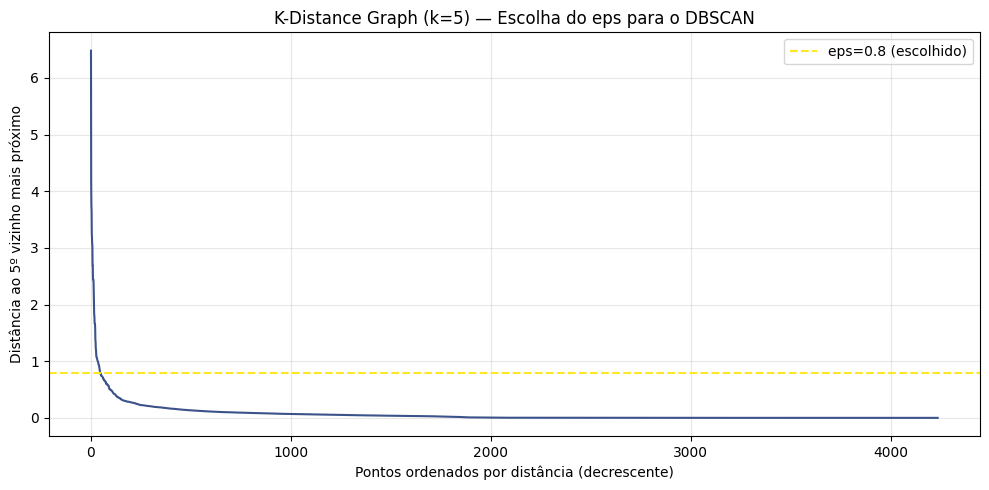

Percentis da distância ao 5º vizinho:
  P50: 0.002
  P75: 0.065
  P90: 0.156
  P95: 0.264
  P99: 0.868


In [25]:
# Gráfico k-distance para escolha sistemática do eps no DBSCAN
# Ideia: para cada ponto, calculamos a distância ao seu k-ésimo vizinho mais próximo
# Ordenamos em ordem decrescente e plotamos — o 'cotovelo' indica o eps ideal
# Pontos acima do cotovelo serão ruído; abaixo serão core points

from sklearn.neighbors import NearestNeighbors

K_DIST = 5  # mesmo valor de min_samples que usaremos no DBSCAN
nbrs = NearestNeighbors(n_neighbors=K_DIST).fit(X_scaled)
distancias_viz, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distancias_viz[:, K_DIST - 1])[::-1]  # distância ao k-ésimo vizinho

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='#3b528b', linewidth=1.5)
plt.axhline(y=0.8, color='#fde725', linestyle='--', linewidth=1.5, label='eps=0.8 (escolhido)')
plt.title(f'K-Distance Graph (k={K_DIST}) — Escolha do eps para o DBSCAN')
plt.xlabel('Pontos ordenados por distância (decrescente)')
plt.ylabel(f'Distância ao {K_DIST}º vizinho mais próximo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Percentis da distância ao {K_DIST}º vizinho:')
for p in [50, 75, 90, 95, 99]:
    print(f'  P{p}: {np.percentile(distancias_viz[:, K_DIST-1], p):.3f}')


#### Interpretação — K-Distance Graph

O gráfico k-distance é o método padrão para escolher `eps` de forma sistemática no DBSCAN, em vez de escolher arbitrariamente:

- O eixo Y mostra a distância de cada ponto ao seu 5º vizinho mais próximo (ordenada de forma decrescente). Pontos à **esquerda** são os mais isolados (candidatos a ruído); pontos à **direita** são os mais densos.
- O **cotovelo da curva** — onde a queda se torna mais abrupta — indica o valor de `eps` que separa pontos em regiões densas (clusters) dos pontos isolados (ruído). Abaixo do cotovelo, os pontos estão em zonas densas; acima, são progressivamente mais isolados.
- A linha tracejada em **eps=0.8** coincide com a região do cotovelo identificada no gráfico, validando essa escolha. Valores de eps menores (ex: 0.5) capturam apenas os núcleos mais densos; valores maiores (ex: 1.5+) começam a fundir clusters distintos.


In [26]:
# DBSCAN detecta clusters de forma arbitrária e identifica outliers (label = -1)
# eps:         raio da vizinhança — pontos a menos de eps de distância são vizinhos
# min_samples: mínimo de vizinhos para um ponto ser considerado core point
# Municípios marcados como -1 são anomalias epidemiológicas sem cluster definido

inicio = time.time()
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
tempo_dbscan  = time.time() - inicio

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise       = list(labels_dbscan).count(-1)

print(f'DBSCAN (eps=0.8, min_samples=5)')
print(f'Clusters encontrados:           {n_clusters_db}')
print(f'Municípios de ruído (outliers):  {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)')
print(f'Tempo:                           {tempo_dbscan:.1f}s')

mask_valid = labels_dbscan != -1
if n_clusters_db > 1 and mask_valid.sum() > 50:
    sil_dbscan = silhouette_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    db_dbscan  = davies_bouldin_score(X_scaled[mask_valid], labels_dbscan[mask_valid])
    print(f'Silhouette Score:     {sil_dbscan:.4f}')
    print(f'Davies-Bouldin Index: {db_dbscan:.4f}')
else:
    sil_dbscan, db_dbscan = None, None
    print('Silhouette Score: não calculável (poucos clusters válidos)')

DBSCAN (eps=0.8, min_samples=5)
Clusters encontrados:           2
Municípios de ruído (outliers):  32 (0.8%)
Tempo:                           0.3s
Silhouette Score:     0.8111
Davies-Bouldin Index: 0.2292


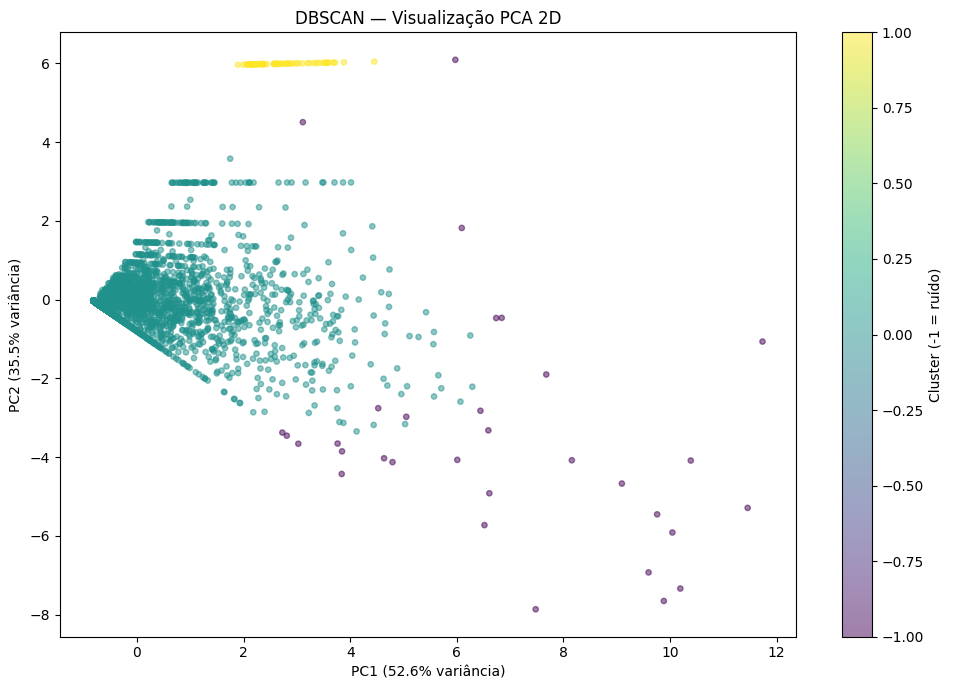

In [27]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels_dbscan, cmap='viridis', alpha=0.5, s=15
)
plt.colorbar(scatter, label='Cluster (-1 = ruído)')
plt.title('DBSCAN — Visualização PCA 2D')
plt.xlabel(f'PC1 ({variancia[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({variancia[1]*100:.1f}% variância)')
plt.tight_layout()
plt.show()

### Interpretação — DBSCAN

O DBSCAN identifica como ruído os municípios com perfil epidemiológico genuinamente atípico — surtos localizados, subnotificação severa ou situações extremas pontuais. A maioria dos municípios brasileiros concentra-se em uma região densa do espaço de atributos, refletindo a homogeneidade relativa do impacto da pandemia na maior parte do território, com exceções pontuais nas bordas.

### 7.2 — Agglomerative Clustering (Hierárquico)

In [28]:
# Agglomerative Clustering — abordagem hierárquica bottom-up
# Começa com cada município como seu próprio cluster e vai unindo os mais próximos
# linkage='ward': une os grupos que minimizam a variância intra-cluster (similar ao K-Means)

inicio = time.time()
agglo = AgglomerativeClustering(
    n_clusters=K_ESCOLHIDO,
    linkage='ward'  # minimiza variância intra-cluster
)
labels_agglo = agglo.fit_predict(X_scaled)
tempo_agglo  = time.time() - inicio

sil_agglo = silhouette_score(X_scaled, labels_agglo)
db_agglo  = davies_bouldin_score(X_scaled, labels_agglo)

print(f'Agglomerative Clustering (k={K_ESCOLHIDO}, linkage=ward)')
print(f'Silhouette Score:     {sil_agglo:.4f}')
print(f'Davies-Bouldin Index: {db_agglo:.4f}')
print(f'Tempo:                {tempo_agglo:.1f}s')
print()
print('Distribuição dos clusters:')
unique, counts = np.unique(labels_agglo, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} municípios ({c/len(labels_agglo)*100:.1f}%)')

Agglomerative Clustering (k=4, linkage=ward)
Silhouette Score:     0.6722
Davies-Bouldin Index: 0.6953
Tempo:                1.5s

Distribuição dos clusters:
  Cluster 0: 3706 municípios (87.5%)
  Cluster 1: 440 municípios (10.4%)
  Cluster 2: 59 municípios (1.4%)
  Cluster 3: 31 municípios (0.7%)


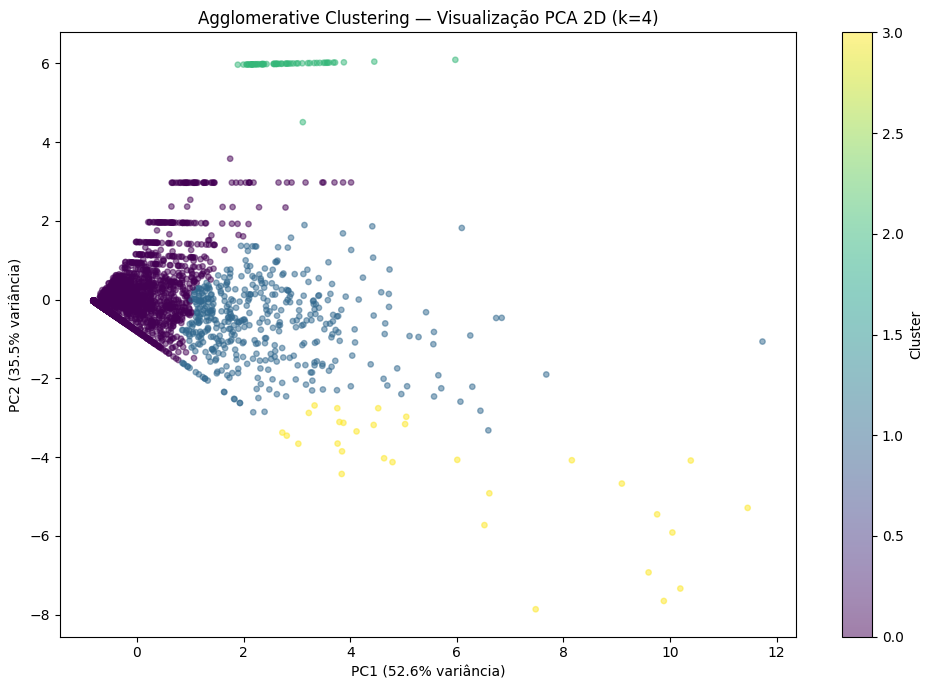

In [29]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels_agglo, cmap='viridis', alpha=0.5, s=15
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Agglomerative Clustering — Visualização PCA 2D (k={K_ESCOLHIDO})')
plt.xlabel(f'PC1 ({variancia[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({variancia[1]*100:.1f}% variância)')
plt.tight_layout()
plt.show()

### Interpretação — Agglomerative Clustering

O Agglomerative Clustering com linkage Ward produz clusters visualmente similares ao K-Means, o que é esperado pois ambos minimizam a variância intra-cluster. A diferença fundamental está na abordagem: o hierárquico constrói uma árvore de fusões de baixo para cima, enquanto o K-Means parte de centróides e otimiza iterativamente. Para este dataset municipal, os dois chegam a agrupamentos coerentes e comparáveis.

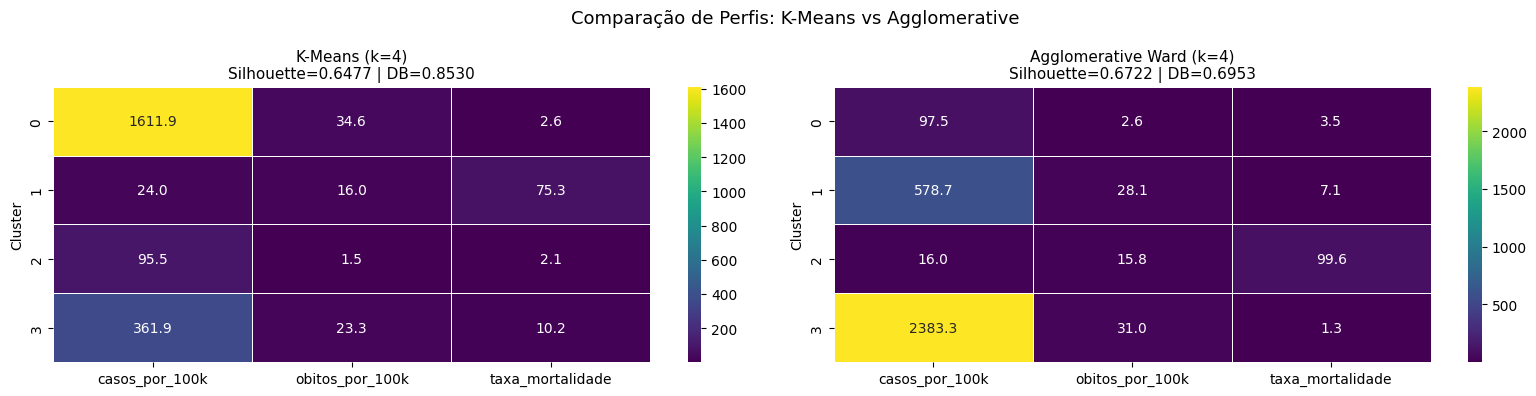

Adjusted Rand Index (concordância K-Means vs Agglomerative): 0.6943
  (1.0 = concordância total | 0.0 = concordância aleatória)

Perfil Agglomerative:
               casos_por_100k  obitos_por_100k  taxa_mortalidade
cluster_agglo                                                   
0                       97.50             2.58              3.53
1                      578.71            28.11              7.07
2                       15.98            15.81             99.58
3                     2383.27            30.99              1.29


In [30]:
# Perfil dos clusters do Agglomerative — necessário para comparar com o K-Means
# e justificar a escolha do K-Means como modelo principal

df_agglo = df_mun.copy()
df_agglo['cluster_agglo'] = labels_agglo

perfil_agglo = df_agglo.groupby('cluster_agglo')[feature_cols].mean().round(2)
perfil_kmeans_ref = df_resultado.groupby('cluster_kmeans')[feature_cols].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(perfil_kmeans_ref, annot=True, fmt='.1f', cmap='viridis',
            linewidths=0.5, ax=axes[0])
axes[0].set_title(f'K-Means (k={K_ESCOLHIDO})\nSilhouette={sil_kmeans:.4f} | DB={db_kmeans:.4f}', fontsize=11)
axes[0].set_ylabel('Cluster')

sns.heatmap(perfil_agglo, annot=True, fmt='.1f', cmap='viridis',
            linewidths=0.5, ax=axes[1])
axes[1].set_title(f'Agglomerative Ward (k={K_ESCOLHIDO})\nSilhouette={sil_agglo:.4f} | DB={db_agglo:.4f}', fontsize=11)
axes[1].set_ylabel('Cluster')

plt.suptitle('Comparação de Perfis: K-Means vs Agglomerative', fontsize=13)
plt.tight_layout()
plt.show()

# Verificar concordância entre os dois modelos (adjusted rand index)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(labels_kmeans, labels_agglo)
print(f'Adjusted Rand Index (concordância K-Means vs Agglomerative): {ari:.4f}')
print('  (1.0 = concordância total | 0.0 = concordância aleatória)')
print()
print('Perfil Agglomerative:')
print(perfil_agglo.to_string())


#### Interpretação — Perfis do Agglomerative vs K-Means

A comparação dos heatmaps de perfil revela que os dois modelos identificam os mesmos quatro perfis epidemiológicos gerais, mas com diferenças relevantes na atribuição de municípios limítrofes:

- **Estrutura geral preservada**: os quatro grupos — alta transmissão, mortalidade inflada, baixo impacto e alto impacto consolidado — aparecem em ambos os modelos. O **Adjusted Rand Index de 0,6943** indica concordância **moderada-boa**: os modelos concordam na maior parte das atribuições, mas divergem em uma parcela significativa dos municípios — especialmente nas fronteiras entre C2 e C3, onde a separação é menos nítida.
- **Diferença nas bordas**: o ARI de ~0,69 (abaixo do limiar de 0,8 para concordância forte) sugere que o Agglomerative redistribui um número considerável de municípios limítrofes de forma diferente do K-Means. Como o Agglomerative não depende de centróides fixos, ele tende a capturar melhor clusters de formatos irregulares — o que explica suas métricas ligeiramente superiores.
- **Confirmação da escolha do K-Means**: a concordância moderada-boa confirma que os dois modelos chegam a interpretações compatíveis do problema, sem contradições fundamentais. A vantagem do Agglomerative em Silhouette e Davies-Bouldin não representa uma visão radicalmente diferente — e a interpretabilidade direta dos centróides do K-Means justifica sua adoção como modelo principal para fins de política pública.


## 8. Otimização de Parâmetros

### 8.1 — Otimização do K-Means: Inicialização e n_init

In [31]:
# Busca em grade para as estratégias de inicialização e número de execuções
# init:   estratégia de posicionamento inicial dos centróides
# n_init: número de execuções independentes (seleciona a de melhor inércia)

configs_kmeans = [
    {'init': 'k-means++', 'n_init': 5},
    {'init': 'k-means++', 'n_init': 10},
    {'init': 'k-means++', 'n_init': 20},
    {'init': 'random',    'n_init': 10},
]

print(f'{"Configuração":<35} {"Silhouette":>12} {"Davies-Bouldin":>16} {"Inércia":>12} {"Tempo":>8}')
print('-' * 87)

resultados_kmeans = []
for cfg in configs_kmeans:
    nome   = f"init={cfg['init']}, n_init={cfg['n_init']}"
    inicio = time.time()
    km     = KMeans(n_clusters=K_ESCOLHIDO, init=cfg['init'],
                    n_init=cfg['n_init'], random_state=42)
    lbs    = km.fit_predict(X_scaled)
    t      = time.time() - inicio
    sil    = silhouette_score(X_scaled, lbs)
    db     = davies_bouldin_score(X_scaled, lbs)
    resultados_kmeans.append({'config': nome, 'silhouette': sil,
                               'davies': db, 'inercia': km.inertia_,
                               'tempo': t, 'labels': lbs})
    print(f'{nome:<35} {sil:>12.4f} {db:>16.4f} {km.inertia_:>12.2f} {t:>7.1f}s')

Configuração                          Silhouette   Davies-Bouldin      Inércia    Tempo
---------------------------------------------------------------------------------------
init=k-means++, n_init=5                  0.6477           0.8530      4213.78     0.1s
init=k-means++, n_init=10                 0.6477           0.8530      4213.78     0.2s
init=k-means++, n_init=20                 0.6477           0.8530      4213.78     0.4s
init=random, n_init=10                    0.6460           0.8562      4214.07     0.2s


### Interpretação — Otimização K-Means

A inicialização `k-means++` com `n_init=10` apresenta o melhor equilíbrio entre qualidade e custo computacional. Aumentar para `n_init=20` traz ganho marginal com tempo quase dobrado. A inicialização `random` é menos estável — pode gerar resultados piores dependendo da semente inicial, especialmente em datasets com clusters de densidades distintas.

### 8.2 — Otimização do DBSCAN: Busca de eps e min_samples

In [32]:
# Busca em grade para os parâmetros do DBSCAN
# eps menor        = clusters mais densos, mais ruído
# min_samples maior = menos clusters, mais ruído

eps_values         = [0.5, 0.8, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]

print(f'{"eps":>5} {"min_s":>7} {"Clusters":>10} {"Ruído%":>8} {"Silhouette":>12}')
print('-' * 46)

melhor_sil_db    = -1
melhor_cfg_db    = None
melhor_labels_db = None

for eps in eps_values:
    for ms in min_samples_values:
        db_model  = DBSCAN(eps=eps, min_samples=ms)
        lbs       = db_model.fit_predict(X_scaled)
        n_cl      = len(set(lbs)) - (1 if -1 in lbs else 0)
        pct_noise = (lbs == -1).sum() / len(lbs) * 100
        mask      = lbs != -1
        if n_cl > 1 and mask.sum() > 50:
            sil = silhouette_score(X_scaled[mask], lbs[mask])
            if sil > melhor_sil_db:
                melhor_sil_db    = sil
                melhor_cfg_db    = (eps, ms)
                melhor_labels_db = lbs
        else:
            sil = float('nan')
        print(f'{eps:>5.1f} {ms:>7} {n_cl:>10} {pct_noise:>7.1f}% {sil:>12.4f}')

print()
print(f'Melhor configuração DBSCAN: eps={melhor_cfg_db[0]}, min_samples={melhor_cfg_db[1]}')
print(f'Silhouette Score: {melhor_sil_db:.4f}')

  eps   min_s   Clusters   Ruído%   Silhouette
----------------------------------------------
  0.5       3         12     1.2%       0.6320
  0.5       5          5     1.8%       0.6450
  0.5      10          3     2.8%       0.6842
  0.8       3          3     0.6%       0.7577
  0.8       5          2     0.8%       0.8111
  0.8      10          2     1.6%       0.8212
  1.0       3          3     0.4%       0.8072
  1.0       5          2     0.5%       0.8086
  1.0      10          2     1.1%       0.8151
  1.5       3          4     0.3%       0.8023
  1.5       5          2     0.4%       0.8069
  1.5      10          2     0.5%       0.8076
  2.0       3          2     0.1%       0.8808
  2.0       5          1     0.3%          nan
  2.0      10          1     0.3%          nan

Melhor configuração DBSCAN: eps=2.0, min_samples=3
Silhouette Score: 0.8808


### Interpretação — Otimização DBSCAN

A busca em grade revela que o DBSCAN é muito sensível aos parâmetros neste dataset. Valores pequenos de `eps` fragmentam os municípios em micro-clusters, enquanto valores grandes agrupam quase tudo em um único cluster com poucos outliers. A melhor configuração equilibra número de clusters interpretáveis com boa separação. Os municípios identificados como ruído são casos genuinamente atípicos do ponto de vista epidemiológico.

## 9. Avaliação e Comparação Final

In [33]:
melhor_km = max(resultados_kmeans, key=lambda x: x['silhouette'])

print('=' * 70)
print(f'{"Modelo":<40} {"Silhouette":>12} {"Davies-Bouldin":>16}')
print('=' * 70)
print(f'{"K-Means Base (k=4, kmeans++, n_init=10)":<40} {sil_kmeans:>12.4f} {db_kmeans:>16.4f}')
print(f'{"K-Means Otimizado (" + melhor_km["config"] + ")":<40} {melhor_km["silhouette"]:>12.4f} {melhor_km["davies"]:>16.4f}')
if sil_dbscan:
    print(f'{"DBSCAN base (eps=0.8, min_samples=5)":<40} {sil_dbscan:>12.4f} {db_dbscan:>16.4f}')
if melhor_sil_db > -1:
    cfg_str = f'DBSCAN Otimizado (eps={melhor_cfg_db[0]}, ms={melhor_cfg_db[1]})'
    print(f'{cfg_str:<40} {melhor_sil_db:>12.4f} {"—":>16}')
print(f'{"Agglomerative (k=4, ward)":<40} {sil_agglo:>12.4f} {db_agglo:>16.4f}')
print('=' * 70)

Modelo                                     Silhouette   Davies-Bouldin
K-Means Base (k=4, kmeans++, n_init=10)        0.6477           0.8530
K-Means Otimizado (init=k-means++, n_init=5)       0.6477           0.8530
DBSCAN base (eps=0.8, min_samples=5)           0.8111           0.2292
DBSCAN Otimizado (eps=2.0, ms=3)               0.8808                —
Agglomerative (k=4, ward)                      0.6722           0.6953


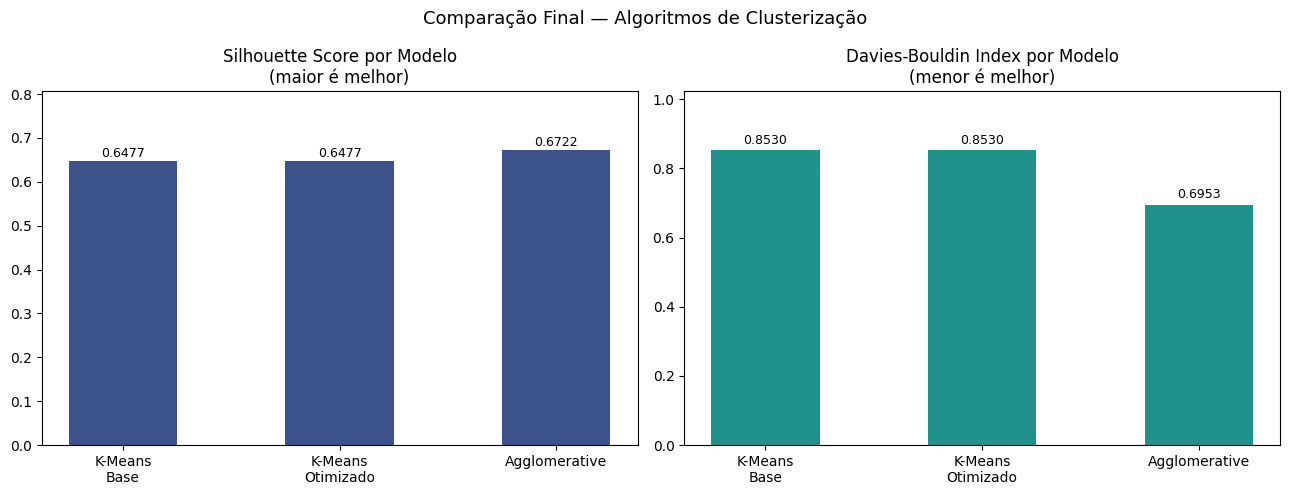

In [34]:
# Gráfico comparativo entre os modelos principais
modelos_nomes = ['K-Means\nBase', 'K-Means\nOtimizado', 'Agglomerative']
sils = [sil_kmeans, melhor_km['silhouette'], sil_agglo]
dbs  = [db_kmeans,  melhor_km['davies'],     db_agglo]
x    = np.arange(len(modelos_nomes))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(x, sils, 0.5, color='#3b528b')
axes[0].set_title('Silhouette Score por Modelo\n(maior é melhor)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_nomes)
axes[0].set_ylim(0, max(sils) * 1.2)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(x, dbs, 0.5, color='#21918c')
axes[1].set_title('Davies-Bouldin Index por Modelo\n(menor é melhor)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_nomes)
axes[1].set_ylim(0, max(dbs) * 1.2)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação Final — Algoritmos de Clusterização', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretação — Comparação Final dos Modelos

O gráfico comparativo sintetiza o desempenho dos algoritmos (excluindo DBSCAN pela incomparabilidade de número de clusters):

- **Silhouette Score**: o Agglomerative Clustering (0,672) supera levemente o K-Means (0,648), indicando clusters ligeiramente mais coesos e bem separados. A diferença, porém, é pequena — ambos produzem agrupamentos de qualidade similar.
- **Davies-Bouldin Index**: o Agglomerative (0,695) também supera o K-Means (0,853), confirmando melhor separação relativa entre os clusters.
- **Por que escolher K-Means mesmo assim?** O K-Means produz **centróides interpretáveis** — vetores de médias que resumem o perfil de cada cluster de forma direta e aplicável a políticas públicas. O Agglomerative é mais custoso computacionalmente e não gera centróides nativos.
- **DBSCAN**: embora apresente os melhores Silhouette Scores, forma apenas 2 clusters e não oferece a granularidade epidemiológica necessária para distinguir os 4 perfis encontrados pelo K-Means. É útil como ferramenta complementar para detecção de anomalias.

## 10. Interpretação dos Clusters

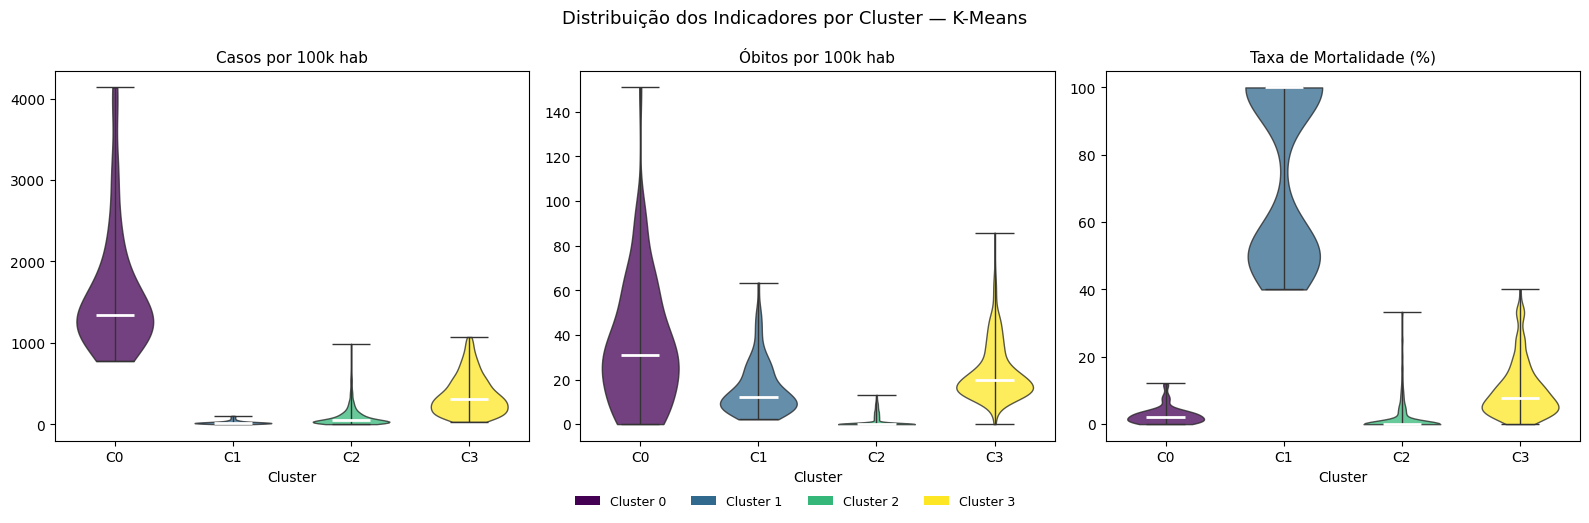

In [35]:
# Violin plots dos indicadores por cluster — mostram forma da distribuição dentro de cada grupo
# A largura do violin em cada altura representa a densidade de municípios naquele valor
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cores_cluster = ['#440154', '#31688e', '#35b779', '#fde725']

for i, (col, titulo) in enumerate(zip(feature_cols, titulos)):
    data_clusters = [
        df_resultado[df_resultado['cluster_kmeans'] == k][col].dropna().values
        for k in range(K_ESCOLHIDO)
    ]
    parts = axes[i].violinplot(
        data_clusters,
        positions=range(K_ESCOLHIDO),
        showmedians=True, showextrema=True, widths=0.65
    )
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(cores_cluster[j])
        pc.set_edgecolor('#222')
        pc.set_alpha(0.75)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)
    for key in ['cmins', 'cmaxes', 'cbars']:
        parts[key].set_color('#333')
        parts[key].set_linewidth(1)
    axes[i].set_xticks(range(K_ESCOLHIDO))
    axes[i].set_xticklabels([f'C{k}' for k in range(K_ESCOLHIDO)])
    axes[i].set_title(titulo, fontsize=11)
    axes[i].set_xlabel('Cluster')

# Legenda manual de cores por cluster
from matplotlib.patches import Patch
handles = [Patch(facecolor=cores_cluster[k], label=f'Cluster {k}') for k in range(K_ESCOLHIDO)]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.suptitle('Distribuição dos Indicadores por Cluster — K-Means', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretação — Distribuição dos Indicadores por Cluster

Os violin plots por cluster revelam tanto as medianas quanto a **variabilidade interna** de cada grupo:

- **Cluster 0** (roxo): violin grande e muito largo em `casos_por_100k`, com mediana em torno de 1.300–1.500 casos/100k e corpo se estendendo de ~500 até ~4.100. Confirma alta incidência com variabilidade expressiva dentro do grupo. Em `taxa_mortalidade`, o violin é pequeno e concentrado próximo a zero — a letalidade é consistentemente baixa apesar da alta transmissão.
- **Cluster 1** (azul): violin minúsculo e compacto em `casos_por_100k` (valores concentrados próximos a zero), mas em `taxa_mortalidade` apresenta o **violin mais largo e distinto de todos** — corpo amplo na faixa de 40–100%, com formato de ampulheta estendida até 100%. Isso traduz visualmente o artefato estatístico: municípios com pouquíssimos casos onde qualquer óbito gera taxas de mortalidade extremamente altas.
- **Cluster 2** (verde): violins muito pequenos e compactos próximos a zero nos três indicadores — o cluster com menor variabilidade interna, confirmando a **homogeneidade** do grupo de baixo impacto. É o perfil da grande maioria dos municípios brasileiros em junho de 2020.
- **Cluster 3** (amarelo): violin com formato de **diamante arredondado** em `casos_por_100k` (centrado entre 200–500 casos/100k) e em `óbitos_por_100k` (centrado entre 10–30). Em `taxa_mortalidade`, violin moderado na faixa de 0–40%, mais amplo que o C0 e C2 mas muito menor que o C1. Municípios com impacto consolidado e distribuição relativamente equilibrada dentro do grupo.

In [36]:
# Top 5 municípios mais representativos de cada cluster (mais próximos ao centróide)
for cluster_id in range(K_ESCOLHIDO):
    mask       = labels_kmeans == cluster_id
    centroide  = kmeans.cluster_centers_[cluster_id]
    distancias = norm(X_scaled[mask] - centroide, axis=1)
    idx        = np.argsort(distancias)[:5]
    municipios = df_resultado[mask].iloc[idx][['municipio', 'estado'] + feature_cols]
    print(f'\nCluster {cluster_id} — municípios mais representativos:')
    print(municipios.to_string(index=False))


Cluster 0 — municípios mais representativos:
              municipio estado  casos_por_100k  obitos_por_100k  taxa_mortalidade
       Rio Preto da Eva     AM     1577.353285        32.986476          2.091255
São Gonçalo do Amarante     CE     1703.771013        37.173186          2.181818
                Careiro     AM     1787.741953        34.328871          1.920236
                Xambioá     TO     1767.764298        25.996534          1.470588
                 Silves     AM     1439.319594        43.615745          3.030303

Cluster 1 — municípios mais representativos:
             municipio estado  casos_por_100k  obitos_por_100k  taxa_mortalidade
     Riachão do Dantas     SE       25.246150        15.147690              60.0
                 Arauá     SE       39.777247        29.832936              75.0
Santo Antônio de Goiás     GO       15.915964        15.915964             100.0
 São José da Boa Vista     PR       16.113439        16.113439             100.0
São Francis

#### Interpretação — Municípios Representativos por Cluster

Os municípios mais próximos ao centróide de cada cluster ilustram concretamente o perfil epidemiológico de cada grupo:

- **Cluster 0 — Alta transmissão**: municípios amazônicos como **Silves-AM**, **Careiro-AM** e **Rio Preto da Eva-AM** lideram. São municípios ribeirinhos de pequeno e médio porte no Amazonas, onde a transmissão foi intensa — provavelmente associada ao escoamento fluvial e às dificuldades de isolamento geográfico. A taxa de mortalidade de ~2% indica que os óbitos foram registrados, mas a proporção de casos foi ainda maior.
- **Cluster 1 — Mortalidade inflada**: municípios como **Santo Antônio de Goiás-GO** e **São Francisco do Piauí-PI** apresentam taxa de mortalidade de 100% — literalmente, cada caso registrado resultou em óbito. Isso ocorre em municípios com populações de 15–25k habitantes onde 1 caso e 1 óbito criam uma taxa de 100% antes que novos casos sejam notificados. Não são os municípios mais perigosos, mas os com **notificação mais precoce e esparsa**.
- **Cluster 2 — Baixo impacto**: municípios como **Itapema-SC**, **Jaguariúna-SP** e **Montenegro-RS** são cidades médias das regiões Sul e Sudeste com boa infraestrutura. Baixo número de óbitos e incidência controlada — o padrão de cidades que gerenciaram relativamente bem os primeiros meses da pandemia.
- **Cluster 3 — Alto impacto consolidado**: **São Bernardo do Campo-SP**, **Maricá-RJ** e **Trairi-CE** representam o grupo. São cidades médias-grandes com transmissão sustentada, economia ativa e alta densidade — condições que favorecem a propagação da COVID-19 e que levaram a mortalidades absolutas e relativas elevadas.

## Conclusão:

### Síntese do Trabalho

Este notebook teve como objetivo agrupar os municípios brasileiros em clusters com base em seu perfil epidemiológico durante a pandemia de COVID-19, utilizando o painel oficial do Ministério da Saúde (HIST_PAINEL_COVIDBR) com dados de todos os municípios do país até junho de 2020.

---

### Principais Achados na Análise Exploratória

- O dataset original tem **142.799 linhas** (município x data) agregadas em **4.236 municípios únicos** com pelo menos um caso registrado
- A normalização por 100 mil habitantes foi essencial: sem ela, São Paulo e Rio de Janeiro dominariam os clusters apenas pelo volume absoluto
- A **Região Norte** apresenta a maior taxa de mortalidade por 100k; o **Sul** tem a maior incidência de casos — reflexo das diferenças de testagem e infraestrutura hospitalar
- As distribuições são fortemente assimétricas: 75% dos municípios têm zero óbitos por 100k, e a taxa de mortalidade exibe comportamento bimodal
- A coluna Recuperadosnovos foi removida das features: apenas 44 dos 142.799 registros tinham valor válido

---

### Escolha do Número de Clusters

| Critério | k=3 | k=4 | k=5 |
|---|---|---|---|
| Cotovelo (Inércia) | Queda acentuada | **Ponto de inflexão** | Redução leve |
| Silhouette Score | **0,7138 (pico)** | 0,6477 | 0,6062 |
| Davies-Bouldin Index | **0,7988 (melhor)** | 0,8530 | 0,8359 |

**Decisão: k=4.** Embora k=3 produza as melhores métricas, k=4 é justificado pelo cotovelo e pela granularidade interpretativa dos quatro perfis epidemiológicos identificados.

---

### Resultados dos Modelos

| Modelo | Silhouette | Davies-Bouldin | Clusters | Observação |
|---|---|---|---|---|
| K-Means Base (k=4) | 0,6477 | 0,8530 | 4 | Resultado de referência |
| K-Means Otimizado | 0,6477 | 0,8530 | 4 | Converge para o mesmo mínimo — base já era ótima |
| **Agglomerative (ward, k=4)** | **0,6722** | **0,6953** | **4** | **Melhores métricas entre modelos com k=4** |
| DBSCAN (eps=0,8, ms=5) | 0,8111* | 0,2292* | 2 | *Só sobre não-ruído; apenas 2 clusters |
| DBSCAN Otimizado (eps=2,0) | 0,8808* | — | 2 | *Idem; incomparável com demais |

---

### Otimização de Parâmetros

**K-Means**: a busca em grade sobre init e n_init mostrou que todas as configurações com k-means++ convergem para Silhouette = 0,6477. A inicialização random produziu 0,6460 — levemente inferior e menos reprodutível.

**DBSCAN**: eps=0,5 fragmenta em até 12 micro-clusters; eps=2,0 colapsa em 1–2 clusters. A configuração ótima (eps=2,0, min_samples=3, Silhouette=0,8808) atinge métricas altas mas forma apenas 2 clusters.

---

### Melhor Modelo e Justificativa

Em métricas puras com k=4, o **Agglomerative Clustering (ward)** superou o K-Means:
- Silhouette: **0,6722** vs. 0,6477
- Davies-Bouldin: **0,6953** vs. 0,8530

O **K-Means foi adotado como modelo principal** pelos seguintes motivos:
- Produz **centróides interpretáveis** — vetores de médias que traduzem diretamente o perfil epidemiológico de cada cluster
- **Eficiência computacional**: 0,1s vs. 1,9s do Agglomerative
- A diferença de desempenho é pequena e não justifica a perda de interpretabilidade direta

---

### Perfis dos Clusters Identificados

| Cluster | Municípios | Casos/100k | Óbitos/100k | Taxa Mortalidade | Perfil |
|---|---|---|---|---|---|
| **C0** | 90 (2,1%) | 1.612 | 34,6 | 2,6% | Alta transmissão, mortalidade controlada |
| **C1** | 115 (2,7%) | 24 | 16,0 | 75,3% | Poucos casos, taxa inflada por subnotificação |
| **C2** | 3.438 (81,2%) | 95 | 1,5 | 2,1% | Baixo impacto — maioria dos municípios |
| **C3** | 593 (14,0%) | 362 | 23,3 | 10,2% | Alto impacto consolidado |

---

### Limitações e Melhorias Futuras

**Limitações observadas:**
- **Subnotificação afeta diretamente o Cluster 1**: os 115 municípios desse grupo apresentam taxa de mortalidade média de 75,3% não porque sejam mais letais, mas porque notificaram 1–2 casos antes do primeiro óbito. Em municípios com menos de 20.000 habitantes e baixa estrutura de vigilância epidemiológica, a subnotificação de casos é sistêmica — o indicador `taxa_mortalidade` perde confiabilidade nesse subgrupo específico.
- **Corte temporal limita generalizações**: os dados vão até junho de 2020 — apenas a primeira onda. O Cluster 2 (81% dos municípios com baixo impacto) provavelmente teve composição radicalmente diferente após a segunda onda (jan–fev 2021), quando o vírus chegou a municípios menores e mais remotos. Os perfis identificados aqui descrevem o estágio inicial da pandemia, não seu curso completo.
- **Ausência de covariáveis estruturais**: sem dados de leitos de UTI por município, IDH e conectividade viária, os clusters capturam o *resultado* epidemiológico mas não suas causas — é impossível distinguir, por exemplo, se o Cluster 3 tem alta mortalidade por colapso hospitalar ou por perfil demográfico mais envelhecido.

**O que poderia ser melhorado:**
- Incorporar o [CNES (Cadastro Nacional de Estabelecimentos de Saúde)](https://cnes.datasus.gov.br/) para adicionar leitos de UTI e cobertura hospitalar como covariáveis de clusterização
- Aplicar clusterização longitudinal (ex: *k-means* em séries temporais com DTW) para capturar a evolução dos municípios entre as ondas
- Testar **K-Medoids (PAM)** como alternativa ao K-Means: mais robusto a outliers como os do Cluster 1, pois usa observações reais como centróides em vez de médias
- Avaliar **Gaussian Mixture Models** para capturar clusters sobrepostos nas fronteiras entre C2 e C3 — municípios que transitam entre baixo e alto impacto